In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
# import warnings
# warnings.filterwarnings('ignore')

In [3]:
plt.style.use('ggplot')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

In [4]:
# Load dataset
df = pd.read_csv('ADANIPORTS.csv')
print("Dataset loaded. Shape:", df.shape)

Dataset loaded. Shape: (3322, 15)


In [5]:
display(df.head())

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,NaN,9859619,0.3612
1,2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,NaN,1453278,0.3172
2,2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,NaN,1069678,0.2088
3,2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,NaN,1260913,0.2735
4,2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123,0.2741


In [6]:
display(df.dtypes)

Date                   object
Symbol                 object
Series                 object
Prev Close            float64
Open                  float64
High                  float64
Low                   float64
Last                  float64
Close                 float64
VWAP                  float64
Volume                  int64
Turnover              float64
Trades                float64
Deliverable Volume      int64
%Deliverble           float64
dtype: object

In [7]:
display(df.describe(include='all'))

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
count,3322,3322,3322,3322.000000,3322.000000,3322.000000,3322.000000,3322.000000,3322.000000,3322.000000,3.322000e+03,3.322000e+03,2.456000e+03,3.322000e+03,3322.000000
unique,3322,2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2021-04-30,ADANIPORTS,EQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,2299,3322,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,344.114314,344.763019,351.608007,337.531969,344.239539,344.201626,344.853182,2.954564e+06,1.070144e+14,4.492259e+04,1.207441e+06,0.445899
std,NaN,NaN,NaN,192.936882,193.619992,198.617808,188.676614,193.187813,193.045886,193.841305,4.104227e+06,2.625564e+14,5.023124e+04,1.398640e+06,0.160496
min,NaN,NaN,NaN,108.000000,108.000000,110.450000,105.650000,108.000000,108.000000,108.340000,1.236600e+04,2.415857e+11,3.660000e+02,5.383000e+03,0.067000
25%,NaN,NaN,NaN,164.312500,164.850000,168.000000,161.600000,164.075000,164.312500,164.855000,7.493682e+05,1.817650e+13,2.083200e+04,3.212005e+05,0.332900
50%,NaN,NaN,NaN,324.700000,325.750000,331.275000,319.850000,325.000000,324.700000,325.765000,2.007292e+06,5.836041e+13,3.588150e+04,8.132775e+05,0.445650
75%,NaN,NaN,NaN,400.912500,401.000000,407.187500,395.000000,400.912500,400.912500,400.607500,3.636883e+06,1.158526e+14,5.336875e+04,1.605528e+06,0.555850


In [8]:
print("\nMissing values:")
display(df.isnull().sum()[df.isnull().sum() > 0])


Missing values:


Trades    866
dtype: int64

In [9]:
# Impute 'Trades' if exists
if 'Trades' in df.columns:
    df['Trades'].fillna(df['Trades'].median(), inplace=True)

In [10]:
# Categorical, binary, and continuous identification
categorical_cols = [col for col in df.columns if df[col].dtype == 'object']
binary_cols = [col for col in df.columns if df[col].dropna().nunique() == 2]
continuous_cols = [col for col in df.columns if col not in categorical_cols + binary_cols]

categorical_cols

['Date', 'Symbol', 'Series']

In [11]:
binary_cols

['Symbol']

In [12]:
continuous_cols

['Prev Close',
 'Open',
 'High',
 'Low',
 'Last',
 'Close',
 'VWAP',
 'Volume',
 'Turnover',
 'Trades',
 'Deliverable Volume',
 '%Deliverble']

In [13]:
# Descriptive stats (mean, median, mode, std, min, max)
print("\nDescriptive Statistics:")
desc_stats = {
    'Mean': df[continuous_cols].mean(),
    'Median': df[continuous_cols].median(),
    'Mode': df[continuous_cols].mode().iloc[0],
    'Std': df[continuous_cols].std(),
    'Min': df[continuous_cols].min(),
    'Max': df[continuous_cols].max()
}
display(pd.DataFrame(desc_stats))


Descriptive Statistics:


,Mean,Median,Mode,Std,Min,Max
Prev Close,3.441143e+02,3.247000e+02,1.379500e+02,1.929369e+02,1.080000e+02,1.307450e+03
Open,3.447630e+02,3.257500e+02,1.430000e+02,1.936200e+02,1.080000e+02,1.310250e+03
High,3.516080e+02,3.312750e+02,1.525000e+02,1.986178e+02,1.104500e+02,1.324000e+03
Low,3.375320e+02,3.198500e+02,1.440000e+02,1.886766e+02,1.056500e+02,1.270000e+03
Last,3.442395e+02,3.250000e+02,1.460000e+02,1.931878e+02,1.080000e+02,1.308000e+03
Close,3.442016e+02,3.247000e+02,1.379500e+02,1.930459e+02,1.080000e+02,1.307450e+03
VWAP,3.448532e+02,3.257650e+02,1.230400e+02,1.938413e+02,1.083400e+02,1.302150e+03
Volume,2.954564e+06,2.007292e+06,1.236600e+04,4.104227e+06,1.236600e+04,9.771788e+07
Turnover,1.070144e+14,5.836041e+13,2.415857e+11,2.625564e+14,2.415857e+11,8.160988e+15
Trades,4.256570e+04,3.588150e+04,3.588150e+04,4.337026e+04,3.660000e+02,1.205984e+06



Normality Tests (Shapiro-Wilk):
Prev Close p-value: 0.0000 - Not normal


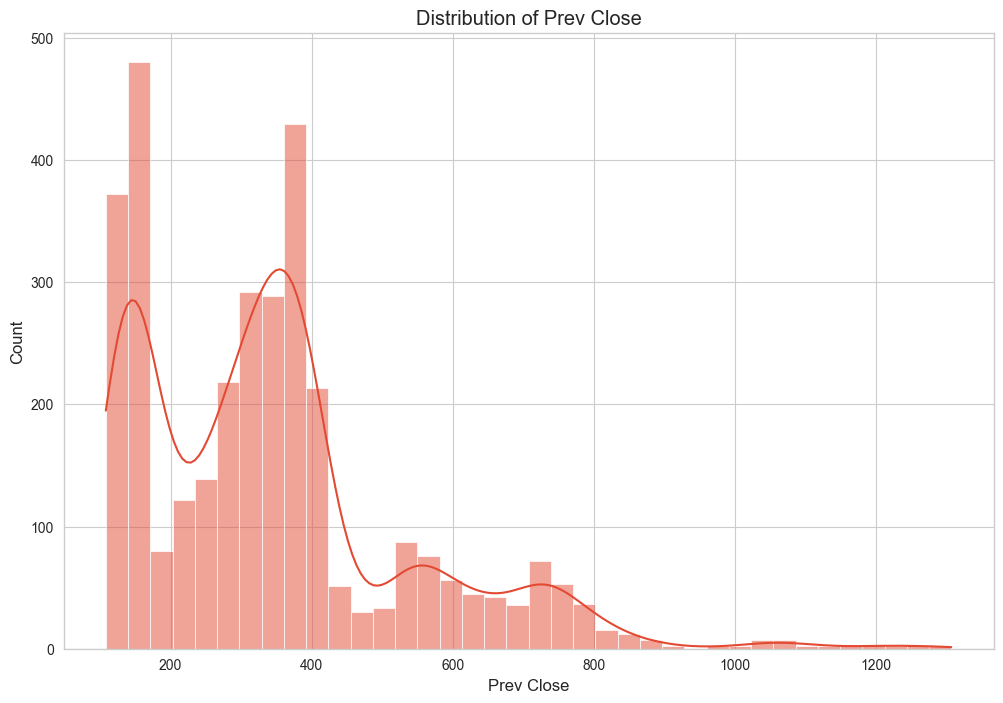

Open p-value: 0.0000 - Not normal


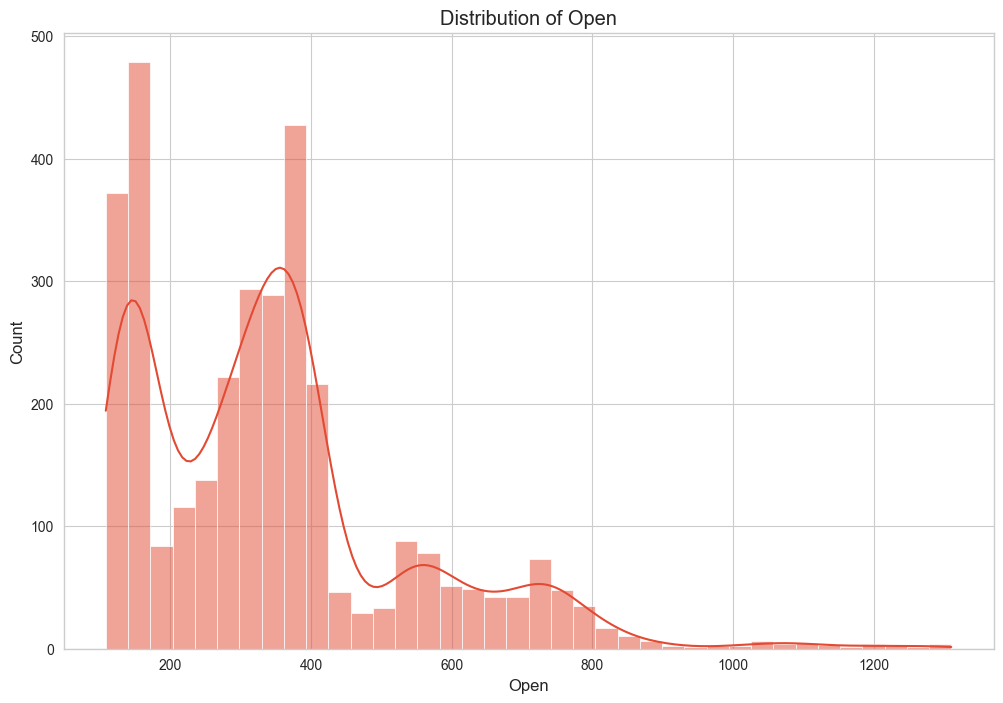

Close p-value: 0.0000 - Not normal


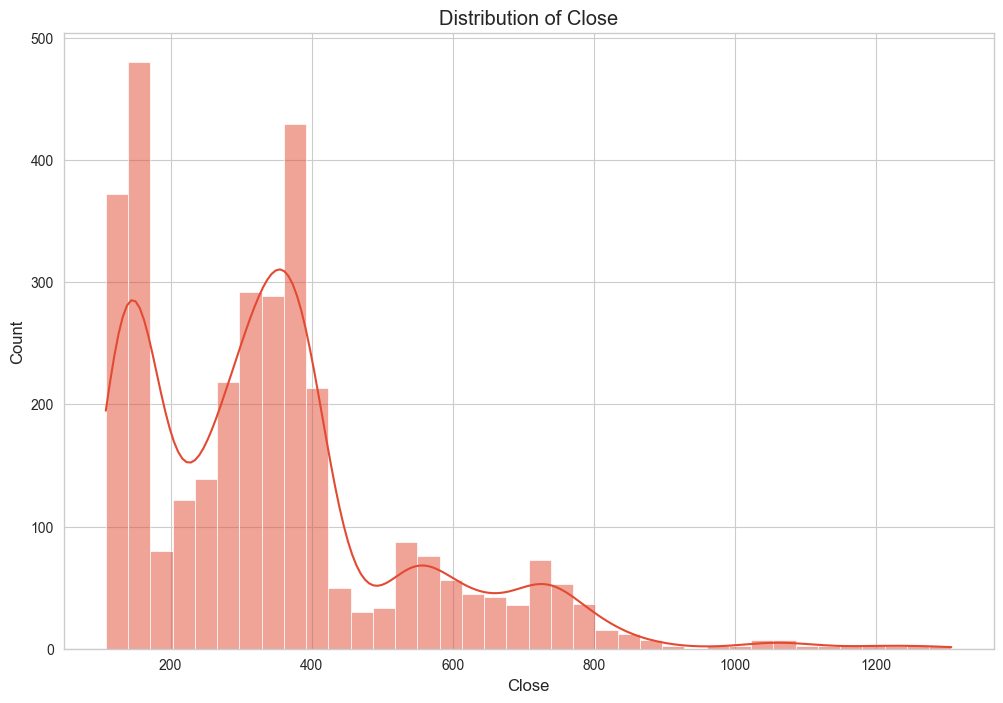

In [14]:
# Normality Check (Shapiro-Wilk Test)
print("\nNormality Tests (Shapiro-Wilk):")
for col in ['Prev Close', 'Open', 'Close']:
    if col in df.columns:
        sample = df[col].dropna().sample(n=min(5000, df[col].dropna().shape[0]))
        stat, p = stats.shapiro(sample)
        print(f"{col} p-value: {p:.4f} - {'Not normal' if p < 0.05 else 'Approximately normal'}")
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
        plt.show()


Correlation Matrix:


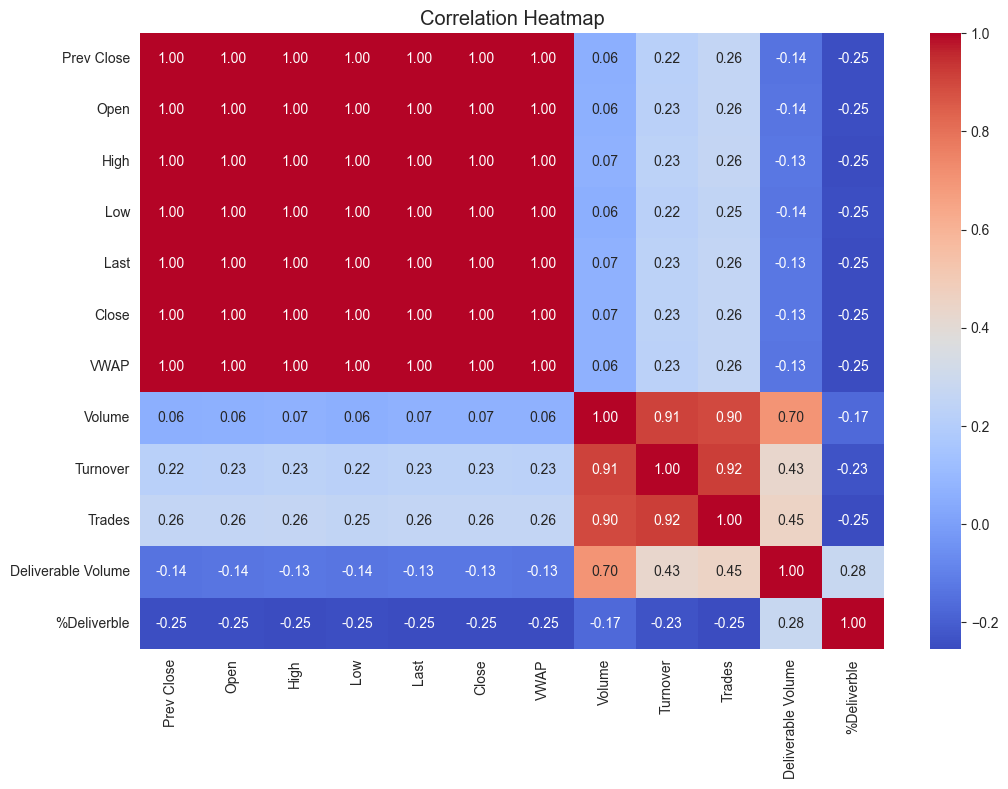

In [15]:
# Correlation Analysis
if len(continuous_cols) > 1:
    print("\nCorrelation Matrix:")
    corr = df[continuous_cols].corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Heatmap')
    plt.show()

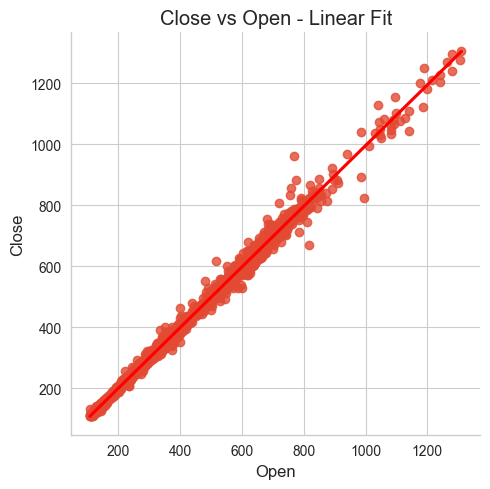

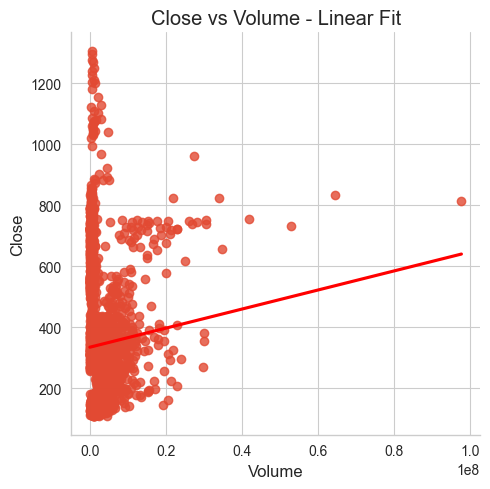

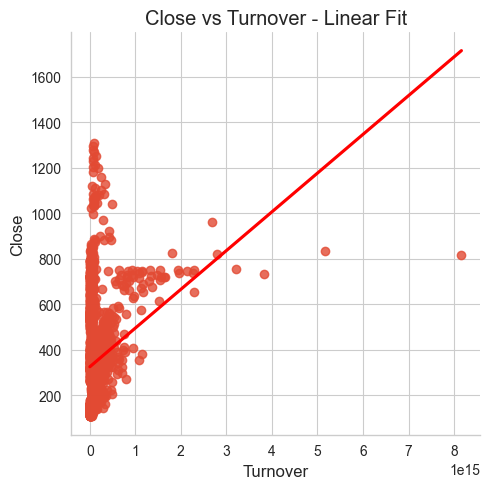

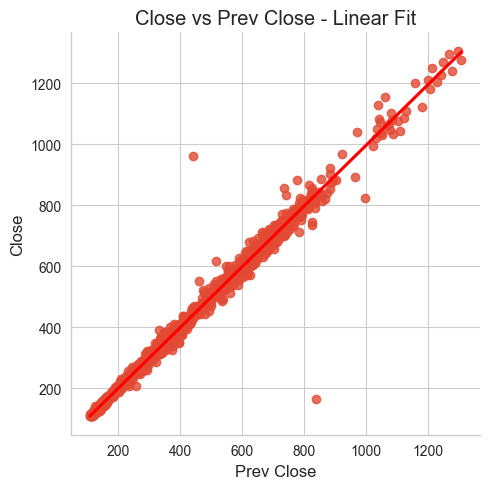

In [16]:
# Simple linearity check without LOWESS
import seaborn as sns
import matplotlib.pyplot as plt

target_col = 'Close'
check_features = ['Open', 'Volume', 'Turnover', 'Prev Close', 'Daily Change']

check_features = [col for col in check_features if col in df.columns]

for feature in check_features:
    sns.lmplot(data=df, x=feature, y=target_col, ci=None, line_kws={"color": "red"})
    plt.title(f'{target_col} vs {feature} - Linear Fit')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [17]:
# Drop highly correlated redundant columns
drop_cols = [col for col in ['Last', 'VWAP', 'High', 'Low'] if col in df.columns]
df.drop(columns=drop_cols, inplace=True)
print(f"Dropped columns due to high correlation or redundancy: {drop_cols}")

Dropped columns due to high correlation or redundancy: ['Last', 'VWAP', 'High', 'Low']


In [18]:
# Feature Engineering
df['Daily Change'] = df['Close'] - df['Open']
df['Change %'] = (df['Daily Change'] / df['Open']) * 100

df['MA_5'] = df['Close'].rolling(window=5).mean()
df['MA_10'] = df['Close'].rolling(window=10).mean()
df['STD_5'] = df['Close'].rolling(window=5).std()
df.fillna(method='bfill', inplace=True)

print("\nNew Features Added: ['Daily Change', 'Change %', 'MA_5', 'MA_10', 'STD_5']")


New Features Added: ['Daily Change', 'Change %', 'MA_5', 'MA_10', 'STD_5']



Outlier Detection - Boxplots:


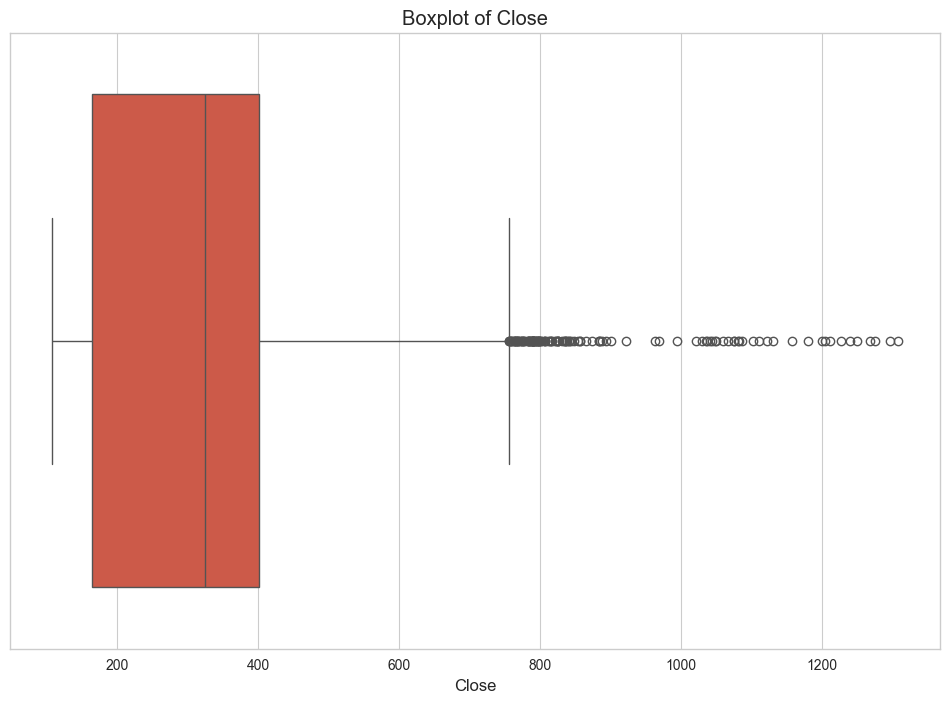

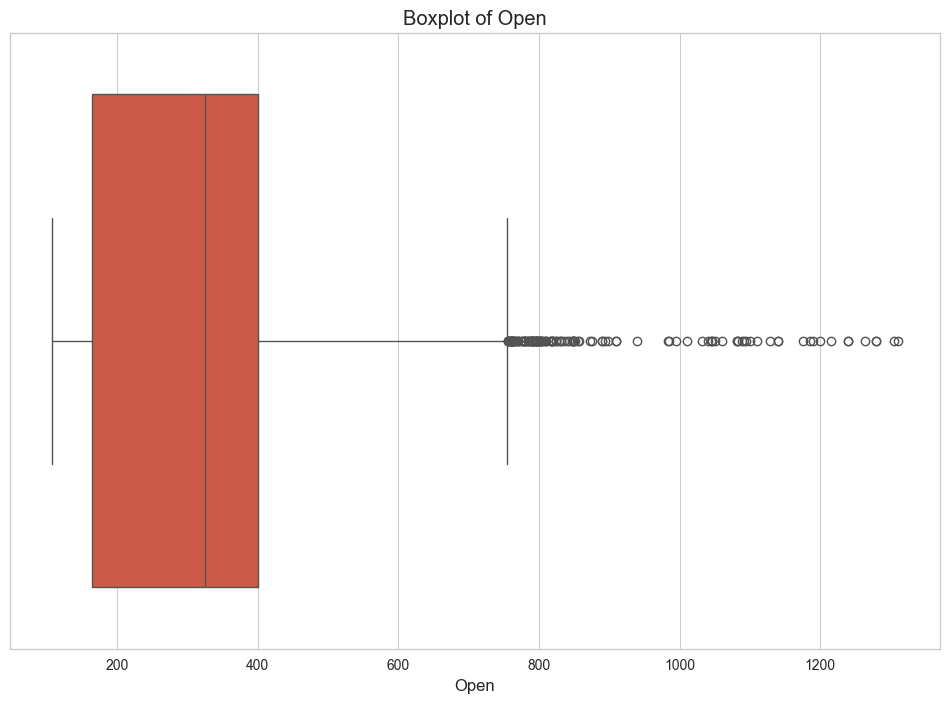

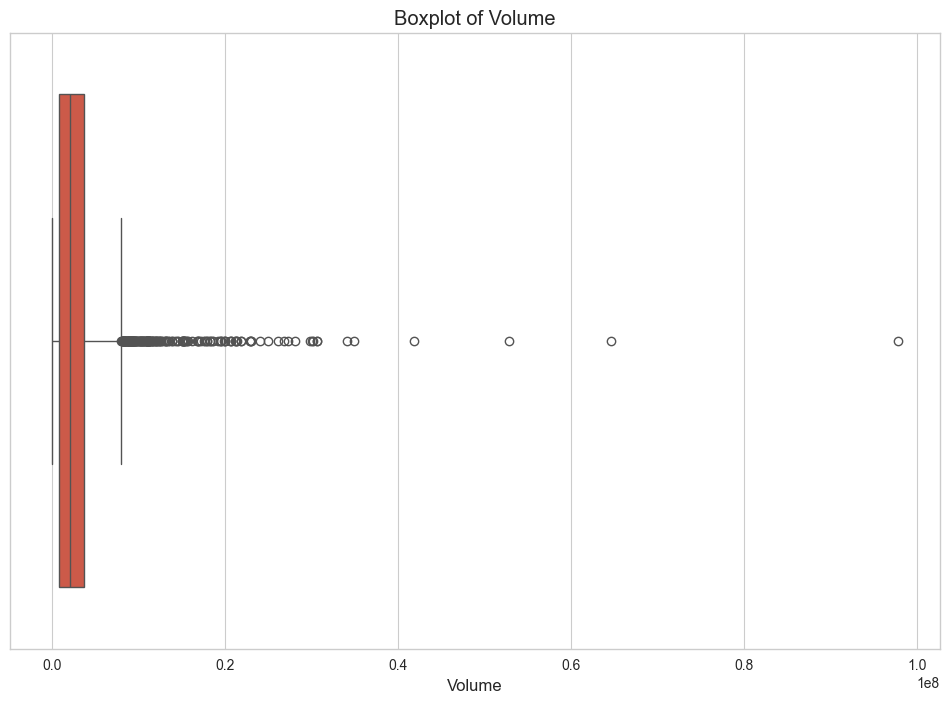

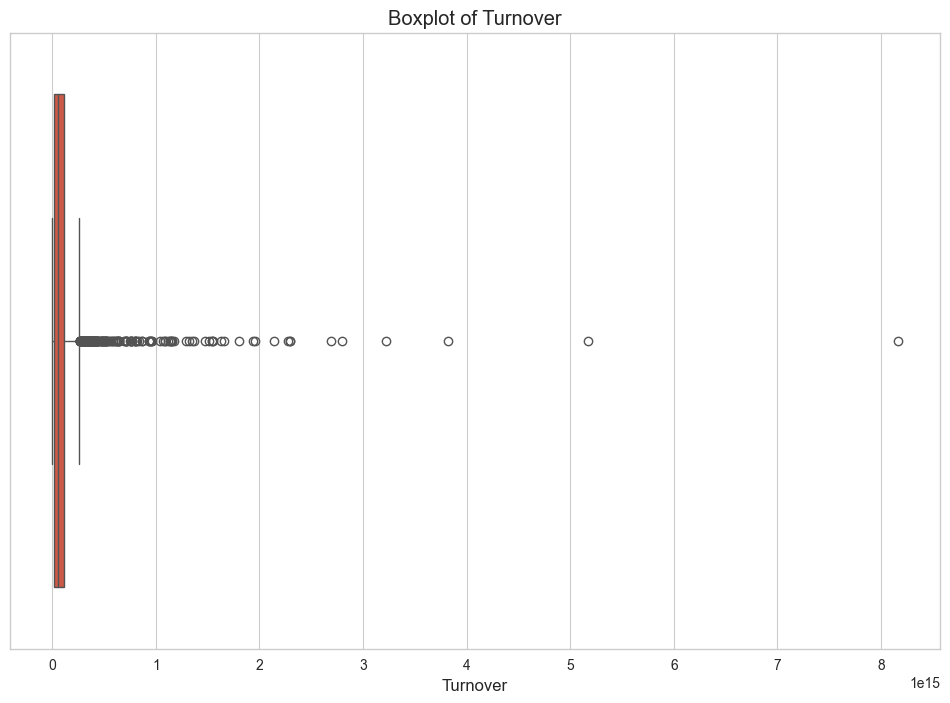

In [19]:
# Boxplots for outlier detection
print("\nOutlier Detection - Boxplots:")
for col in ['Close', 'Open', 'Volume', 'Turnover']:
    if col in df.columns:
        sns.boxplot(x=df[col])
        plt.title(f'Boxplot of {col}')
        plt.show()

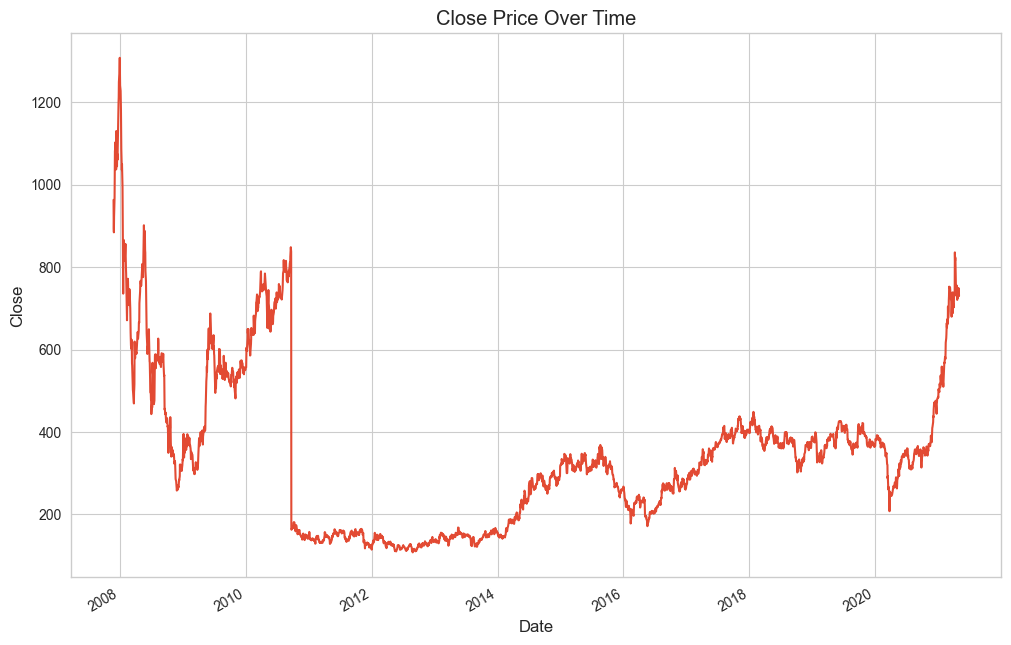

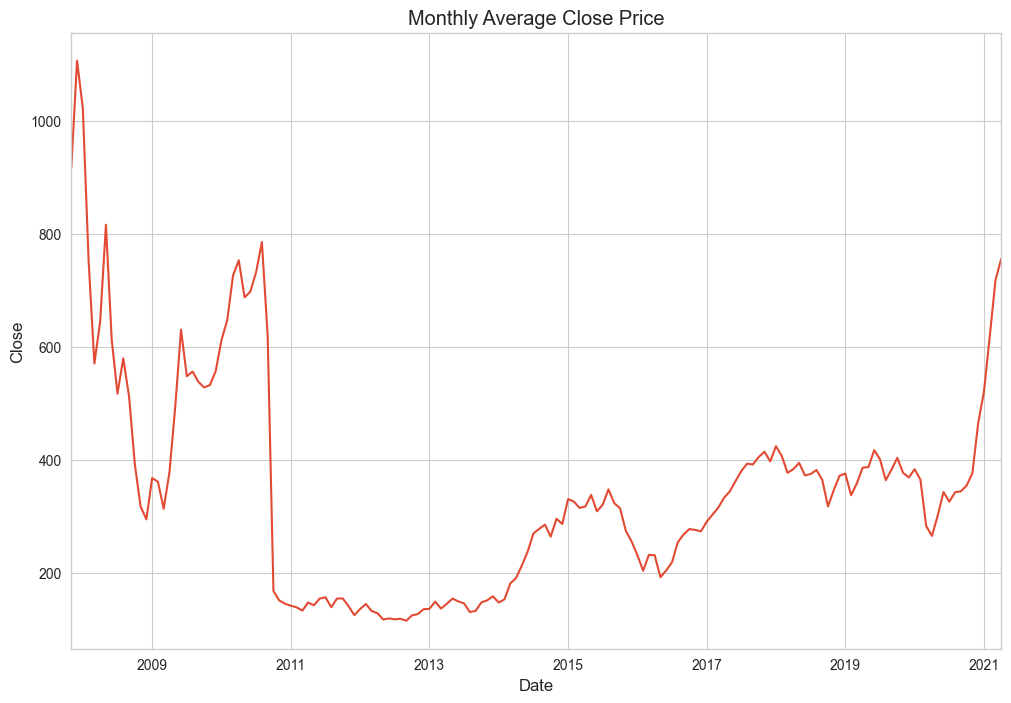

In [20]:
# Time series visualization
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

    if 'Close' in df.columns:
        df['Close'].plot()
        plt.title('Close Price Over Time')
        plt.ylabel('Close')
        plt.show()

    monthly_avg = df['Close'].resample('M').mean()
    monthly_avg.plot()
    plt.title('Monthly Average Close Price')
    plt.ylabel('Close')
    plt.show()

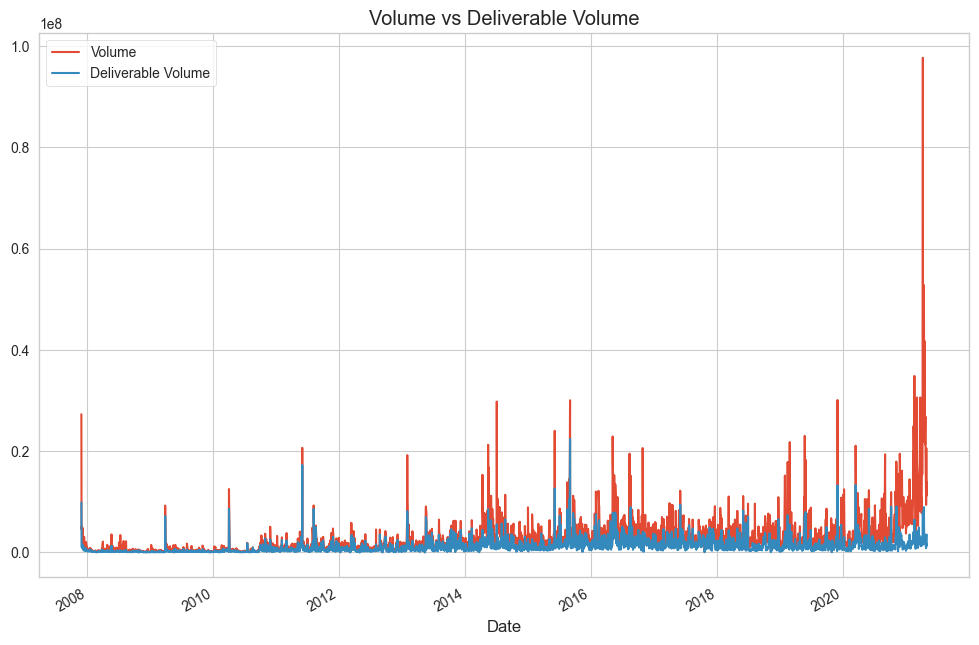

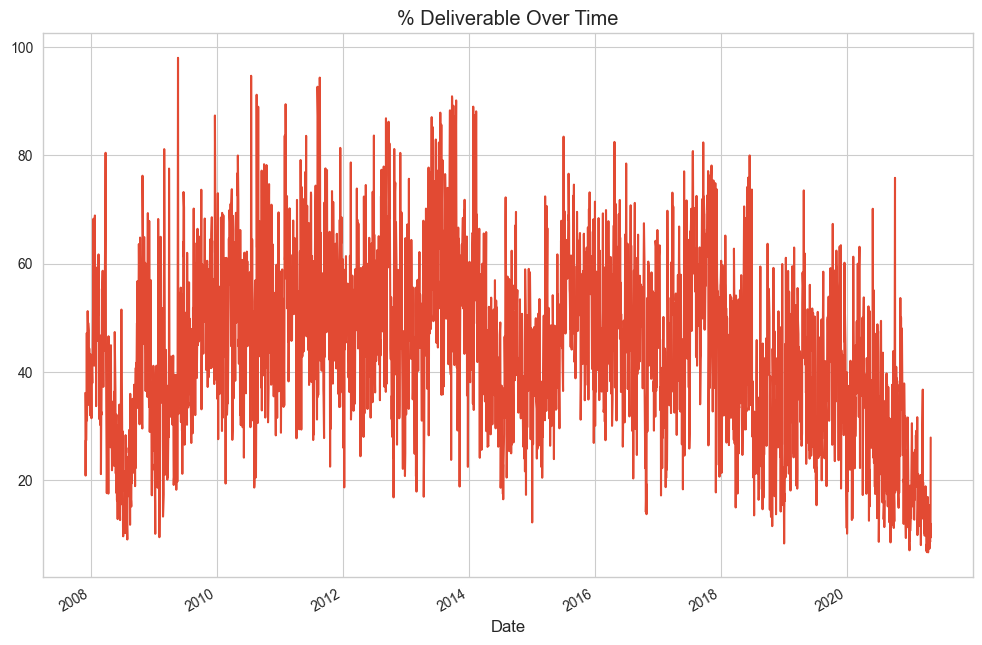

In [21]:
# Volume trends
if 'Volume' in df.columns and 'Deliverable Volume' in df.columns:
    df['%Deliverble'] = (df['Deliverable Volume'] / df['Volume']) * 100
    df[['Volume', 'Deliverable Volume']].plot()
    plt.title('Volume vs Deliverable Volume')
    plt.show()

    df['%Deliverble'].plot()
    plt.title('% Deliverable Over Time')
    plt.show()

In [22]:
# Final dataset shape and columns
print("\nFinal Shape:", df.shape)


Final Shape: (3322, 15)


In [23]:
print("Columns after preprocessing:\n", df.columns.tolist())

Columns after preprocessing:
 ['Symbol', 'Series', 'Prev Close', 'Open', 'Close', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume', '%Deliverble', 'Daily Change', 'Change %', 'MA_5', 'MA_10', 'STD_5']
